# **Projec Title Fake news Detection**

Libraries Required First

```

```



In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

Loading Dataset  

In [ ]:
Fake_path='/content/drive/MyDrive/Fake.csv'
True_path='/content/drive/MyDrive/True.csv'
Fake_df=pd.read_csv(Fake_path)
True_df=pd.read_csv(True_path)

Labeling Data  and combining data

In [ ]:
Fake_df['Lable']=0
True_df['Lable']=1
data=pd.concat([Fake_df,True_df],ignore_index=True)
data = data.sample(frac=1).reset_index(drop=True)
print(data.head())

                                               title  \
0  BREAKING BAD: John McCain’s Campaign Rocked by...   
1  MAYORAL CANDIDATE In DIE-HARD DEMOCRAT City Ma...   
2   Watch This Democratic Congressman OBLITERATE ...   
3  ‘IT’S ALL ABOUT THE KIDS’…JUST ASK THE UNIONS:...   
4  Russia says retreat of Syrian opposition figur...   

                                                text      subject  \
0  21st Century Wire asks Will this be the beginn...  Middle-east   
1  If John Persinger wins the mayoral race in Eri...    left-news   
2  Rep. Mark Takano (D-Calif.) pummeled the Repub...         News   
3  If the Chicago Public Schools were a business ...    left-news   
4  MOSCOW/BEIRUT (Reuters) - Russia said on Tuesd...    worldnews   

                 date  Lable  
0      April 28, 2016      0  
1         Oct 8, 2017      0  
2      March 24, 2016      0  
3         Jul 3, 2015      0  
4  November 21, 2017       1  


# Step 2: Text Preprocessing

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
data=data[['text','Lable']]
stop_Words=set(stopwords.words('english'))
def clean_text(text):
  text=text.lower()
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  words=word_tokenize(text)
  words=[word for word in words if word not in stop_Words]
  return ' '.join(words)

data['clean_text']=data['text'].apply(clean_text)
print(data[['clean_text', 'Lable']].head())


                                          clean_text  Lable
0  st century wire asks beginning end john mccain...      0
1  john persinger wins mayoral race erie pa next ...      0
2  rep mark takano dcalif pummeled republicans xe...      0
3  chicago public schools business private sector...      0
4  moscowbeirut reuters russia said tuesday resig...      1


In [ ]:
print(data)

                                                    text  Lable  \
0      21st Century Wire asks Will this be the beginn...      0   
1      If John Persinger wins the mayoral race in Eri...      0   
2      Rep. Mark Takano (D-Calif.) pummeled the Repub...      0   
3      If the Chicago Public Schools were a business ...      0   
4      MOSCOW/BEIRUT (Reuters) - Russia said on Tuesd...      1   
...                                                  ...    ...   
44893  WASHINGTON (Reuters) - U.S. Republican preside...      1   
44894  The media really wants to bury Trump on this b...      0   
44895  Protesters were out in large numbers on Michig...      0   
44896  (Reuters) - The White House on Tuesday denied ...      1   
44897  So much for the promise of transparency from O...      0   

                                              clean_text  
0      st century wire asks beginning end john mccain...  
1      john persinger wins mayoral race erie pa next ...  
2      rep mark ta

# Step 3: Split the Dataset (Training & Testing Sets)

In [ ]:
X=data['clean_text']
y=data['Lable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))
print("Training set size:", len(y_train))
print("Testing set size:", len(y_test))


Training set size: 35918
Testing set size: 8980
Training set size: 35918
Testing set size: 8980


 1. Visualize the Dataset Using Graphs

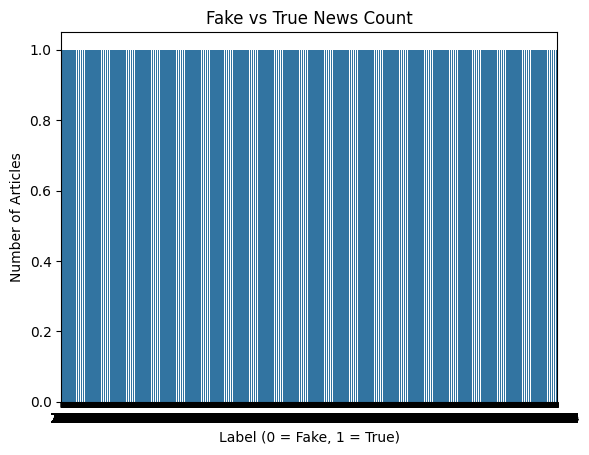

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data['Lable'])
plt.title('Fake vs True News Count')
plt.xlabel('Label (0 = Fake, 1 = True)')
plt.ylabel('Number of Articles')
plt.show()

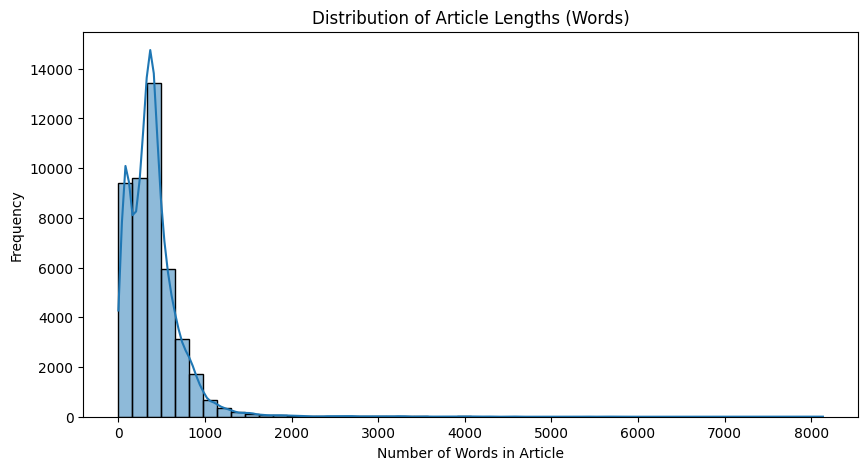

In [ ]:
data['text_length'] = data['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.histplot(data['text_length'], bins=50, kde=True)
plt.title('Distribution of Article Lengths (Words)')
plt.xlabel('Number of Words in Article')
plt.ylabel('Frequency')
plt.show()

Characteristics ofthe data set

In [ ]:
print(" First 5 rows of the dataset:")
print(data.head(), "\n")
print("Shape of the dataset:")
print(f"Total Rows: {data.shape[0]}, Total Columns: {data.shape[1]}\n")

print("Column data types:")
print(data.dtypes, "\n")
print("Count of Fake (0) and True (1) news:")

print(data['Lable'].value_counts(), "\n")


data['text_length'] = data['text'].apply(lambda x: len(str(x).split()))


print("Article length stats (in words):")
print(data['text_length'].describe(), "\n")


 First 5 rows of the dataset:
                                                text  Lable  \
0  21st Century Wire asks Will this be the beginn...      0   
1  If John Persinger wins the mayoral race in Eri...      0   
2  Rep. Mark Takano (D-Calif.) pummeled the Repub...      0   
3  If the Chicago Public Schools were a business ...      0   
4  MOSCOW/BEIRUT (Reuters) - Russia said on Tuesd...      1   

                                          clean_text  text_length  
0  st century wire asks beginning end john mccain...          849  
1  john persinger wins mayoral race erie pa next ...          868  
2  rep mark takano dcalif pummeled republicans xe...          282  
3  chicago public schools business private sector...          649  
4  moscowbeirut reuters russia said tuesday resig...          457   

Shape of the dataset:
Total Rows: 44898, Total Columns: 4

Column data types:
text           object
Lable           int64
clean_text     object
text_length     int64
dtype: object 


# Logistic Rgression

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:

def train_and_evaluate(ngram_range, X_train, X_test, y_train, y_test):
    print(f"\nTraining model with n-gram range: {ngram_range}")


    vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=5000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)


    model = LogisticRegression()
    model.fit(X_train_vec, y_train)


    y_pred = model.predict(X_test_vec)


    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "True"])
    disp.plot(cmap="Blues")


    return accuracy


Training model with n-gram range: (1, 1)
Accuracy: 0.9882
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4739
           1       0.98      0.99      0.99      4241

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



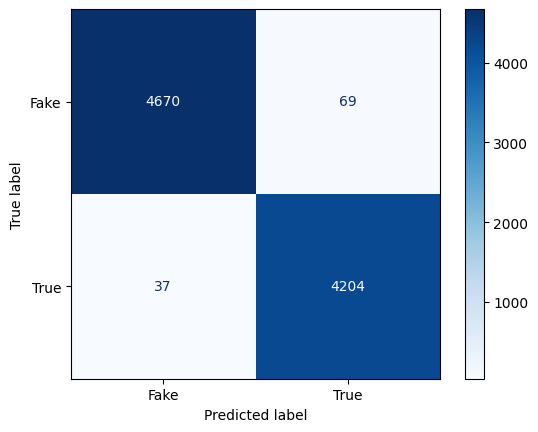

In [ ]:
acc_1gram = train_and_evaluate((1, 1), X_train, X_test, y_train, y_test)


Training model with n-gram range: (2, 2)
Accuracy: 0.9807
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4739
           1       0.98      0.98      0.98      4241

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



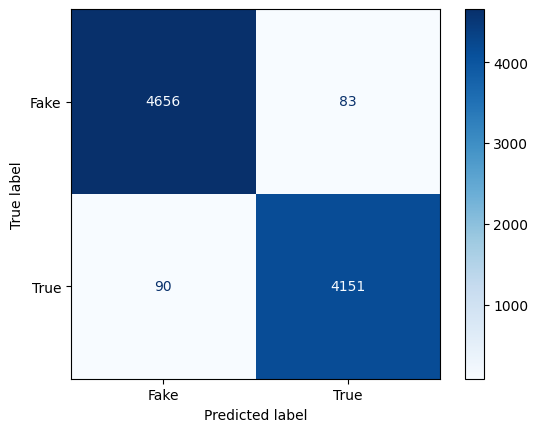

In [ ]:
acc_2gram = train_and_evaluate((2, 2), X_train, X_test, y_train, y_test)


Training model with n-gram range: (3, 3)
Accuracy: 0.9502
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4739
           1       0.97      0.92      0.95      4241

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



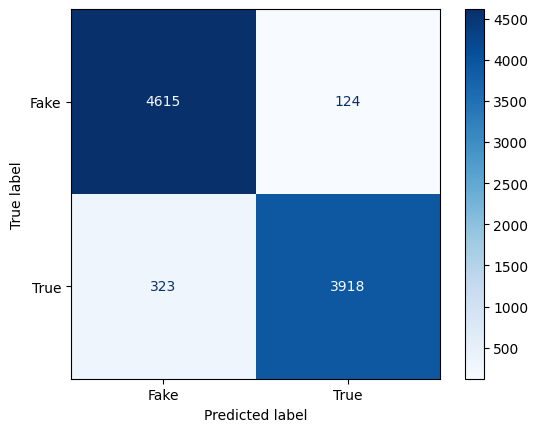

In [ ]:
acc_3gram = train_and_evaluate((3, 3), X_train, X_test, y_train, y_test)

In [ ]:
print("\nAccuracy Comparison:")
print(f"1-gram Accuracy: {acc_1gram:.4f}")
print(f"2-gram Accuracy: {acc_2gram:.4f}")
print(f"3-gram Accuracy: {acc_3gram:.4f}")



Accuracy Comparison:
1-gram Accuracy: 0.9882
2-gram Accuracy: 0.9807
3-gram Accuracy: 0.9502


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def train_rf_with_ngrams(ngram_range, X_train, X_test, y_train, y_test):
    print(f"\n Training Random Forest with n-gram range: {ngram_range}")


    vectorizer = TfidfVectorizer(ngram_range=ngram_range)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)


    rf_model = RandomForestClassifier(n_estimators=100, max_features=5000,random_state=42)
    rf_model.fit(X_train_vec, y_train)


    y_pred = rf_model.predict(X_test_vec)



    accuracy = accuracy_score(y_test, y_pred)
    print(f" Accuracy: {accuracy:.4f}")
    print(" Classification Report:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "True"])
    disp.plot(cmap="Blues")


    return accuracy



 Training Random Forest with n-gram range: (1, 1)
 Accuracy: 0.9968
 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4739
           1       1.00      1.00      1.00      4241

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



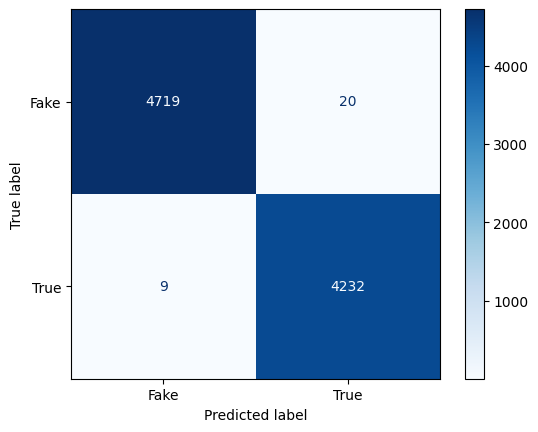

In [ ]:
acc_rf_1gram = train_rf_with_ngrams((1, 1), X_train, X_test, y_train, y_test)


 Training Random Forest with n-gram range: (2, 2)
 Accuracy: 0.9811
 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4739
           1       0.97      0.99      0.98      4241

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



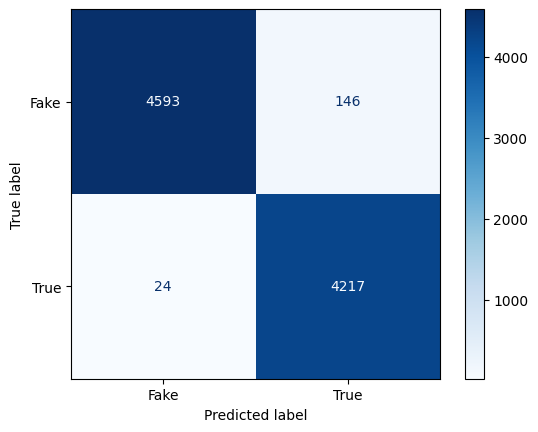

In [ ]:
acc_rf_2gram = train_rf_with_ngrams((2, 2), X_train, X_test, y_train, y_test)


 Training Random Forest with n-gram range: (3, 3)
 Accuracy: 0.9459
 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4682
           1       0.95      0.93      0.94      4298

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



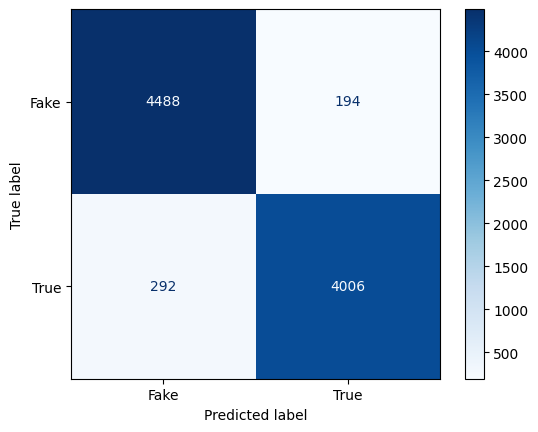

In [ ]:
acc_rf_3gram = train_rf_with_ngrams((3, 3), X_train, X_test, y_train, y_test)

In [ ]:
print("\n Random Forest Accuracy Comparison:")
print(f"1-gram Accuracy: {acc_rf_1gram:.4f}")
print(f"2-gram Accuracy: {acc_rf_2gram:.4f}")
print(f"3-gram Accuracy: {acc_rf_3gram:.4f}")



 Random Forest Accuracy Comparison:
1-gram Accuracy: 0.9979
2-gram Accuracy: 0.9802
3-gram Accuracy: 0.9448


# MLP Classifier

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
def train_mlp_with_ngrams(ngram_range, X_train, X_test, y_train, y_test):
    print(f"\n Training MLPClassifier with n-gram range: {ngram_range}")

    # Step 1: TF-IDF Vectorization
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=5000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)


    mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    mlp_model.fit(X_train_vec, y_train)


    y_pred = mlp_model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    return accuracy


In [ ]:
acc_mlp_1gram = train_mlp_with_ngrams((1, 1), X_train, X_test, y_train, y_test)


 Training MLPClassifier with n-gram range: (1, 1)
Accuracy: 0.9931
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4703
           1       0.99      0.99      0.99      4277

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
acc_mlp_2gram = train_mlp_with_ngrams((2, 2), X_train, X_test, y_train, y_test)


 Training MLPClassifier with n-gram range: (2, 2)
Accuracy: 0.9852
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4703
           1       0.99      0.98      0.98      4277

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
acc_mlp_3gram = train_mlp_with_ngrams((3, 3), X_train, X_test, y_train, y_test)


 Training MLPClassifier with n-gram range: (3, 3)
Accuracy: 0.9428
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      4703
           1       0.96      0.92      0.94      4277

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



# Saving The best Model(Random Forest (1,1))

In [ ]:
import joblib

In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X_train_vec = vectorizer.fit_transform(X_train)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vec, y_train)
X_test_vec = vectorizer.transform(X_test)
y_pred = rf_model.predict(X_test_vec)
print(" Accuracy:", accuracy_score(y_test, y_pred))
print(" Classification Report:\n", classification_report(y_test, y_pred))


In [ ]:
joblib.dump(rf_model, 'random_forest_1gram_model.pkl')
joblib.dump(vectorizer, 'tfidf_1gram_vectorizer.pkl')

NameError: name 'rf_model' is not defined

In [ ]:
model = joblib.load("random_forest_1gram_model.pkl")
vectorizer = joblib.load("tfidf_1gram_vectorizer.pkl")

# Test on new user input
new_text = input(" Enter a news article headline or text:\n")
new_text_vec = vectorizer.transform([new_text])
prediction = model.predict(new_text_vec)

if prediction[0] == 0:
    print("Prediction: This news is likely **FAKE**.")
else:
    print(" Prediction: This news is likely **TRUE**.")


 Enter a news article headline or text:
Many people have raised the alarm regarding the fact that Donald Trump is dangerously close to becoming an autocrat. The thing is, democracies become autocracies right under the people s noses, because they can often look like democracies in the beginning phases. This was explained by Republican David Frum just a couple of months into Donald Trump s presidency, in a piece in The Atlantic called  How to Build an Autocracy. In fact, if you really look critically at what is happening right now   the systematic discrediting of vital institutions such as the free press and the Federal Bureau of Investigation as well the direct weaponization of the Department of Justice in order to go after Trump s former political opponent, 2016 Democratic nominee Hillary Clinton, and you have the makings of an autocracy. We are more than well on our way. Further, one chamber of Congress, the House of Representatives, already has a rogue band of Republicans who are ru

# Building A gui

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
import os
os.listdir()


['.config',
 'tfidf_1gram_vectorizer.pkl',
 'random_forest_1gram_model.pkl',
 'drive',
 'sample_data']